# South Africa 2011 Census 

### Useful Variables

Original Study: year of birth, race, education, employment and income.

P01_YEAR
P05_POP_GROUP (1: Black African, 2: Colored, 3: Indian or Asian, 4: White, 5: Other)
P16_INCOME (1-12, 99: Unspecified)
P20_EDULEVEL (0-29, 98: No Schooling)
P23A_EMPLOYMENTSTATUS (1: Yes, 2: No, 3: Do not know)

In [13]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [ ]:
file_path = 'data/sa-census-2011-person-prov-1to5-v2-20150825-stata/sa-census-2011-person-prov-1to5-v1.2-20150825.dta'
columns_to_keep = ['P01_YEAR', 'F03_SEX', 'P05_POP_GROUP', 'P16_INCOME', 'P20_EDULEVEL', 'P23A_EMPLOYMENTSTATUS']

reader = pd.read_stata(
    file_path, 
    columns=columns_to_keep,
    chunksize=100000, 
    convert_categoricals=False
)

df_list = []
for chunk in reader:
    chunk = chunk[(chunk['P16_INCOME'] != 99) & (chunk['P23A_EMPLOYMENTSTATUS'] != 3)]
    for col in chunk.columns:
        chunk[col] = pd.to_numeric(chunk[col], downcast='integer')
        
    df_list.append(chunk)


df = pd.concat(df_list, ignore_index=True)
# categorical variable mapping
race_map = {1: 'Black African', 2: 'Coloured', 3: 'Indian/Asian', 4: 'White', 5: 'Other'}
emp_map = {1: 'Employed', 2: 'Unemployed'}
gen_map = {1: 'Male', 2: 'Female'}
df['F03_SEX'] = df['F03_SEX'].map(gen_map).astype('category')
df['P16_INCOME'] = df['P16_INCOME'].astype('category')
df['P20_EDULEVEL'] = df['P20_EDULEVEL'].astype('category')
df['P05_POP_GROUP'] = df['P05_POP_GROUP'].map(race_map).astype('category')
df['P23A_EMPLOYMENTSTATUS'] = df['P23A_EMPLOYMENTSTATUS'].map(emp_map).astype('category')

In [2]:
df.head()

,P01_YEAR,F03_SEX,P05_POP_GROUP,P16_INCOME,P20_EDULEVEL,P23A_EMPLOYMENTSTATUS
0,1957,Female,Coloured,4.0,7.0,Employed
1,1978,Male,Coloured,1.0,8.0,Unemployed
2,1987,Female,Coloured,1.0,6.0,Unemployed
3,2007,Female,Coloured,2.0,NaN,NaN
4,2010,Male,Coloured,2.0,NaN,NaN


In [3]:
df.describe()

,P01_YEAR
count,2.078515e+06
mean,1.982209e+03
std,2.034389e+01
min,1.891000e+03
25%,1.969000e+03
50%,1.986000e+03
75%,1.999000e+03
max,2.011000e+03


In [4]:
df.isna().sum()

P01_YEAR                      0
F03_SEX                       0
P05_POP_GROUP                 0
P16_INCOME                45227
P20_EDULEVEL             258004
P23A_EMPLOYMENTSTATUS    650218
dtype: int64

In [5]:
# income data wrangling. . . saddle up cowboy
df_filtered = df[df['P05_POP_GROUP'].isin(['Coloured', 'White'])].copy()

midpoint_map = {
    1: 0,            # No income
    2: 2400,         # R 1 - R 4,800
    3: 7200,         # R 4,801 - R 9,600
    4: 14400,        # R 9,601 - R 19,200
    5: 28800,        # R 19,201 - R 38,400
    6: 57600,        # R 38,401 - R 76,800
    7: 115200,       # R 76,801 - R 153,600
    8: 230400,       # R 153,601 - R 307,200
    9: 460800,       # R 307,201 - R 614,400
    10: 921600,      # R 614,401 - R 1,228,800
    11: 1843200,     # R 1,228,801 - R 2,457,600
    12: 3686400      # R 2,457,601 or more (Lower bound * 1.5)
}
# apply the map
df_filtered['real_income'] = df_filtered['P16_INCOME'].map(midpoint_map).astype(float)

# log income o'clock
df_filtered['log_income'] = np.log1p(df_filtered['real_income'])
df_filtered.head()

,P01_YEAR,F03_SEX,P05_POP_GROUP,P16_INCOME,P20_EDULEVEL,P23A_EMPLOYMENTSTATUS,real_income,log_income
0,1957,Female,Coloured,4.0,7.0,Employed,14400.0,9.575053
1,1978,Male,Coloured,1.0,8.0,Unemployed,0.0,0.000000
2,1987,Female,Coloured,1.0,6.0,Unemployed,0.0,0.000000
3,2007,Female,Coloured,2.0,NaN,NaN,2400.0,7.783641
4,2010,Male,Coloured,2.0,NaN,NaN,2400.0,7.783641


Duplicate key in file PosixPath('/home/erinbrzusek/.config/matplotlib/stylelib/lab-1.2.mplstyle'), line 11 ('axes.facecolor : #f5f0fa')
Duplicate key in file PosixPath('/home/erinbrzusek/.config/matplotlib/stylelib/lab-1.2.mplstyle'), line 35 ('xtick.labelsize : 12')
Duplicate key in file PosixPath('/home/erinbrzusek/.config/matplotlib/stylelib/lab-1.2.mplstyle'), line 36 ('ytick.labelsize : 12')
Duplicate key in file PosixPath('/home/erinbrzusek/.config/matplotlib/stylelib/lab-1.2.mplstyle'), line 40 ('legend.fontsize : 12')
Bad value in file PosixPath('/home/erinbrzusek/.config/matplotlib/stylelib/lab-1.2.mplstyle'), line 11 ('axes.facecolor : #f5f0fa'): Key axes.facecolor: '' does not look like a color arg
Bad value in file PosixPath('/home/erinbrzusek/.config/matplotlib/stylelib/lab-1.2.mplstyle'), line 16 ('grid.color : #999999'): Key grid.color: '' does not look like a color arg
Bad value in file PosixPath('/home/erinbrzusek/.config/matplotlib/stylelib/lab-1.2.mplstyle'), line 20

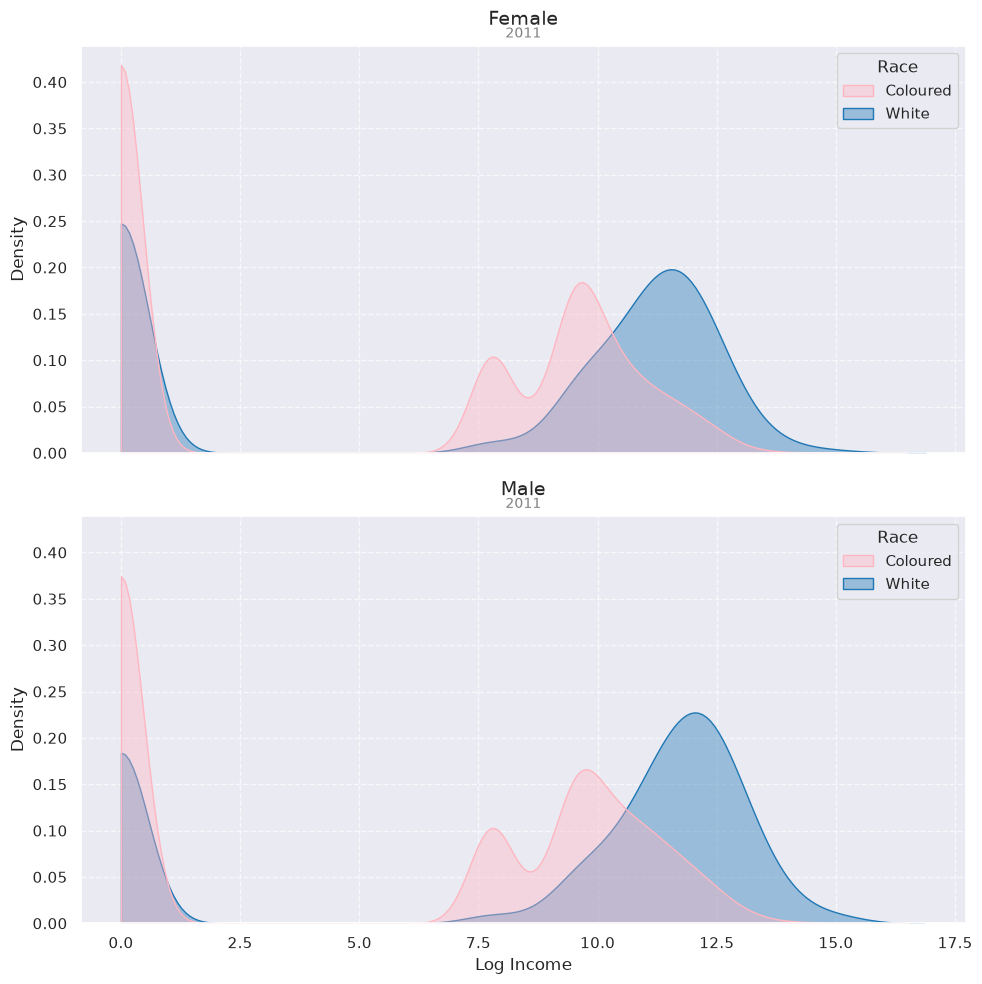

In [6]:
# plots
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")

# df['log_income'] = np.log1p(df['P16_INCOME'])
df_filtered['P05_POP_GROUP'] = df_filtered['P05_POP_GROUP'].cat.remove_unused_categories()

# color palette
custom_palette = {'Coloured': '#FFB6C1', 'White': '#1F77B4'}  
# 2x1 grid layout
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 10), sharex=True, sharey=True)

genders = ['Female', 'Male']

for i, gender in enumerate(genders):
    ax = axes[i]
    # filter for the specific gender loop
    subset = df_filtered[df_filtered['F03_SEX'] == gender]
    
    sns.kdeplot(
        data=subset,
        x='log_income',
        hue='P05_POP_GROUP',
        palette=custom_palette,
        fill=True,
        alpha=0.4,
        ax=ax,
        common_norm=False,
        clip=(0, None) # don't allow negative vals 
    )
    # formatting
    ax.get_legend().set_title("Race")
    ax.grid(True, linestyle='--', alpha=0.7, color='white')
    ax.set_title(gender, fontsize=14, pad=15)
    ax.set_xlabel('Log Income')  
    ax.set_ylabel('Density', fontsize=12)
    # subtitle
    ax.text(0.5, 1.02, '2011', transform=ax.transAxes, ha='center', fontsize=10, color='gray')

plt.tight_layout()
plt.show()

In [7]:
# table
import pandas as pd

# dummy variables
df_filtered['is_employed'] = (df_filtered['P23A_EMPLOYMENTSTATUS'] == 'Employed').astype(int)
df_filtered['is_white'] = (df_filtered['P05_POP_GROUP'] == 'White').astype(int)
df_filtered['P20_EDULEVEL'] = df_filtered['P20_EDULEVEL'].astype(float)

# table rows
vars_to_analyze = {
    'is_white': 'White',
    'P20_EDULEVEL': 'Years of education',
    'is_employed': 'Employed',
    'log_income': 'Log income'
}

# group by gender & calculate mean
summary = df_filtered.groupby('F03_SEX')[list(vars_to_analyze.keys())].agg(['mean', 'std', 'count'])

summary = summary.stack(level=0)

summary = summary.rename(index=vars_to_analyze)
summary.columns = ['Mean', 'SD', 'N']

summary = summary.reorder_levels(['F03_SEX', None])

# formatting
formatted_table = summary.copy()
formatted_table['Mean'] = formatted_table['Mean'].map('{:,.2f}'.format)
formatted_table['SD'] = formatted_table['SD'].map('{:,.2f}'.format)
formatted_table['N'] = formatted_table['N'].map('{:,}'.format)

display(formatted_table)

Mean     SD        N
F03_SEX                                          
Female  White                0.33   0.47  232,424
        Years of education  13.71  16.44  210,334
        Employed             0.31   0.46  232,424
        Log income           5.74   5.21  226,145
Male    White                0.32   0.47  214,505
        Years of education  13.70  16.46  191,359
        Employed             0.38   0.49  214,505
        Log income           6.52   5.32  207,721

In [ ]:
# !pip install pymc
# !pip install arviz
# !pip install xarray
# !pip install graphviz

In [9]:
df_filtered.head()

,P01_YEAR,F03_SEX,P05_POP_GROUP,P16_INCOME,P20_EDULEVEL,P23A_EMPLOYMENTSTATUS,real_income,log_income,is_employed,is_white
0,1957,Female,Coloured,4.0,7.0,Employed,14400.0,9.575053,1,0
1,1978,Male,Coloured,1.0,8.0,Unemployed,0.0,0.000000,0,0
2,1987,Female,Coloured,1.0,6.0,Unemployed,0.0,0.000000,0,0
3,2007,Female,Coloured,2.0,NaN,NaN,2400.0,7.783641,0,0
4,2010,Male,Coloured,2.0,NaN,NaN,2400.0,7.783641,0,0


### Ordinary Least Squares Regression

In [20]:
# filter missing values
df_regression = df_filtered[
    (df_filtered['real_income'] > 0) & 
    (df_filtered['P20_EDULEVEL'].notna()) &
    (df_filtered['P23A_EMPLOYMENTSTATUS'].notna())
].copy()

# birth year wrangling
df_regression['yob_centered'] = df_filtered['P01_YEAR'] - df_filtered['P01_YEAR'].mean()

# log income for positive earners only
df_regression['log_income'] = np.log(df_regression['real_income'])

# partition by gender
df_women = df_regression[df_regression['F03_SEX'] == 'Female']
df_men = df_regression[df_regression['F03_SEX'] == 'Male']

In [24]:
formula = "log_income ~ is_white + is_employed + C(P20_EDULEVEL) + yob_centered"

print("=========================================")
print("2011 WOMEN OLS")
print("=========================================\n")
model_women = smf.ols(formula, data=df_women).fit()
print(model_women.summary())

2011 WOMEN OLS

                            OLS Regression Results                            
Dep. Variable:             log_income   R-squared:                       0.467
Model:                            OLS   Adj. R-squared:                  0.467
Method:                 Least Squares   F-statistic:                     2947.
Date:                Fri, 17 Jul 2026   Prob (F-statistic):               0.00
Time:                        15:22:14   Log-Likelihood:            -1.5178e+05
No. Observations:              111059   AIC:                         3.036e+05
Df Residuals:                  111025   BIC:                         3.040e+05
Df Model:                          33                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept 

In [23]:
print("\n\n=========================================")
print("2011 MEN OLS")
print("=========================================\n")
model_men = smf.ols(formula, data=df_men).fit()
print(model_men.summary())



2011 MEN OLS

                            OLS Regression Results                            
Dep. Variable:             log_income   R-squared:                       0.499
Model:                            OLS   Adj. R-squared:                  0.499
Method:                 Least Squares   F-statistic:                     3378.
Date:                Fri, 17 Jul 2026   Prob (F-statistic):               0.00
Time:                        15:22:06   Log-Likelihood:            -1.5817e+05
No. Observations:              111937   AIC:                         3.164e+05
Df Residuals:                  111903   BIC:                         3.167e+05
Df Model:                          33                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept 

# 2001 Census Data just in case (ugh)

In [14]:
path = "data/SA Census 2001 Person_stata_pr1-5/SA Census 2001 Person_stata_pr1-5/SA Census 2001 Person_v1.1_20111024_pr1_5.dta"

import pandas as pd
import numpy as np

reader = pd.read_stata(
    path, 
    #columns=columns_to_keep,
    chunksize=100000, 
    convert_categoricals=False
)

df_list = []
for chunk in reader:
    for col in chunk.columns:
        chunk[col] = pd.to_numeric(chunk[col], downcast='integer')
        
    df_list.append(chunk)

print(df_list)

[              sn  munic_co  md_code  dc_munic  pr_code  ea_type  EATYPE96  \
0      100000424       572      504       572        5        4         1   
1      100000424       572      504       572        5        4         1   
2      100000440       572      504       572        5        4         1   
3      100000440       572      504       572        5        4         1   
4      100000440       572      504       572        5        4         1   
...          ...       ...      ...       ...      ...      ...       ...   
99995  100521788       171      101       171        1        4         1   
99996  100521788       171      101       171        1        4         1   
99997  100521788       171      101       171        1        4         1   
99998  100521788       171      101       171        1        4         1   
99999  100521788       171      101       171        1        4         1   

       DENSITY  h23_quar  p01_pno  ...  p22_incm  der60_mg  der61_mg  \
0 

### Notes from Office Hours 

- Pushing torwards the asymptote of causaulity: OLS on 2011 data
- Move on to 2001 data d/t learning YOB term